## 1. library Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("모든 라이브러리가 성공적으로 로드되었습니다!")

모든 라이브러리가 성공적으로 로드되었습니다!


## 2. Count Matrix 로드 및 확인

STAR의 `ReadsPerGene.out.tab` 파일에서 unstranded count 데이터를 읽어와 DataFrame으로 변환합니다.

In [3]:
# Count matrix 읽어오기
counts_df = pd.read_csv("../snakefile/counts_matrix.csv", index_col=0)

print(f"Count matrix shape: {counts_df.shape}")
print(f"Samples: {counts_df.columns.tolist()}")
print("\nFirst 10 rows:")
counts_df.head(10)

Count matrix shape: (38618, 6)
Samples: ['SRR4420293', 'SRR4420294', 'SRR4420295', 'SRR4420296', 'SRR4420297', 'SRR4420298']

First 10 rows:


,SRR4420293,SRR4420294,SRR4420295,SRR4420296,SRR4420297,SRR4420298
gene_id,,,,,,
gene-AT1G01010,11,1,8,28,11,13
gene-AT1G01020,33,3,24,83,22,16
gene-AT1G03987,0,0,1,1,0,0
gene-AT1G01030,6,2,11,38,12,13
gene-AT1G01040,19,5,18,129,46,24
gene-AT1G03993,0,0,0,0,0,0
gene-AT1G01046,0,0,0,0,0,0
rna-NR_138613.1,0,0,0,0,0,0
gene-AT1G01050,43,13,64,236,75,39


## 3. Metadata 생성

샘플을 WT 그룹과 atrx-1 그룹으로 나눕니다.
- WT: SRR4420293, SRR4420294, SRR4420295
- atrx-1: SRR4420296, SRR4420297, SRR4420298

In [5]:
# Metadata 생성
metadata = pd.DataFrame({
    'sample': counts_df.columns,
    'condition': ['WT', 'WT', 'WT', 'atrx-1', 'atrx-1', 'atrx-1']
})
metadata = metadata.set_index('sample')
print("Metadata:")
metadata

Metadata:


,condition
sample,
SRR4420293,WT
SRR4420294,WT
SRR4420295,WT
SRR4420296,atrx-1
SRR4420297,atrx-1
SRR4420298,atrx-1


## 4. PyDESeq2 Single Factor Analysis 수행

DeseqDataSet을 생성하고 차등 발현 유전자 분석을 수행합니다.

In [10]:
# Count matrix를 transpose (PyDESeq2는 샘플이 행, 유전자가 열이어야 함)
counts_df_t = counts_df.T
print(f"Transposed count matrix shape: {counts_df_t.shape}")
print(f"  - Rows (samples): {counts_df_t.shape[0]}")
print(f"  - Columns (genes): {counts_df_t.shape[1]}")
print("\nFirst 10 columns of transposed matrix:")
counts_df_t.iloc[:, :10]

Transposed count matrix shape: (6, 38618)
  - Rows (samples): 6
  - Columns (genes): 38618

First 10 columns of transposed matrix:


gene_id,gene-AT1G01010,gene-AT1G01020,gene-AT1G03987,gene-AT1G01030,gene-AT1G01040,gene-AT1G03993,gene-AT1G01046,rna-NR_138613.1,gene-AT1G01050,gene-AT1G03997
SRR4420293,11,33,0,6,19,0,0,0,43,0
SRR4420294,1,3,0,2,5,0,0,0,13,0
SRR4420295,8,24,1,11,18,0,0,0,64,0
SRR4420296,28,83,1,38,129,0,0,0,236,0
SRR4420297,11,22,0,12,46,0,0,0,75,0
SRR4420298,13,16,0,13,24,0,0,0,39,0


In [11]:
# DeseqDataSet 생성
dds = DeseqDataSet(
    counts=counts_df_t,
    metadata=metadata,
    design_factors="condition",
    refit_cooks=True,
    n_cpus=4
)

print("DeseqDataSet이 성공적으로 생성되었습니다!")

DeseqDataSet이 성공적으로 생성되었습니다!


/tmp/ipykernel_4188553/354179879.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [12]:
# DESeq2 분석 실행
print("Running DESeq2...")
dds.deseq2()
print("DESeq2 분석이 완료되었습니다!")

Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
Fitting dispersions...
... done in 5.21 seconds.

Fitting dispersion trend curve...
... done in 5.21 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 5.59 seconds.

Fitting LFCs...
... done in 5.59 seconds.

Fitting LFCs...


DESeq2 분석이 완료되었습니다!


... done in 5.00 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [13]:
# Statistical tests 수행
print("Running statistical tests...")
stat_res = DeseqStats(dds, contrast=["condition", "atrx-1", "WT"])
stat_res.summary()

# 결과 추출
results = stat_res.results_df
print(f"\n총 분석된 유전자 수: {len(results)}")
results.head(10)

Running statistical tests...


Running Wald tests...


Log2 fold change & Wald test p-value: condition atrx-1 vs WT
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
gene_id                                                                      
gene-AT1G01010   9.008198        0.092841  0.651205  0.142567  0.886632   NaN
gene-AT1G01020  21.268311       -0.510983  0.439544 -1.162529  0.245021   NaN
gene-AT1G03987   0.228485       -1.613494  3.736323 -0.431840  0.665858   NaN
gene-AT1G01030   9.849382        0.266624  0.618096  0.431363  0.666204   NaN
gene-AT1G01040  25.495756        0.677787  0.408216  1.660363  0.096841   NaN
...                   ...             ...       ...       ...       ...   ...
gene-ArthCt118   0.000000             NaN       NaN       NaN       NaN   NaN
gene-ArthCp083   4.353927        0.422234  0.923932  0.456996  0.647674   NaN
gene-ArthCt111   0.211738       -1.545408  3.842351 -0.402204  0.687534   NaN
gene-ArthCp084   0.462440       -1.425170  2.814583 -0.506352  0.612610   NaN
gen

... done in 5.77 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
gene-AT1G01010,9.008198,0.092841,0.651205,0.142567,0.886632,NaN
gene-AT1G01020,21.268311,-0.510983,0.439544,-1.162529,0.245021,NaN
gene-AT1G03987,0.228485,-1.613494,3.736323,-0.431840,0.665858,NaN
gene-AT1G01030,9.849382,0.266624,0.618096,0.431363,0.666204,NaN
gene-AT1G01040,25.495756,0.677787,0.408216,1.660363,0.096841,NaN
gene-AT1G03993,0.000000,NaN,NaN,NaN,NaN,NaN
gene-AT1G01046,0.000000,NaN,NaN,NaN,NaN,NaN
rna-NR_138613.1,0.000000,NaN,NaN,NaN,NaN,NaN
gene-AT1G01050,54.141465,-0.058880,0.323446,-0.182039,0.855552,0.953134


## 5. 유의한 유전자 필터링

padj < 0.05 및 |log2FoldChange| > 1 기준으로 유의한 유전자를 필터링합니다.

In [14]:
# Significant genes 필터링
sig_genes = results[(results['padj'] < 0.05) & (abs(results['log2FoldChange']) > 1)]
print(f"유의한 유전자 수 (padj < 0.05, |log2FC| > 1): {len(sig_genes)}")
print(f"\nUp-regulated: {len(sig_genes[sig_genes['log2FoldChange'] > 1])}")
print(f"Down-regulated: {len(sig_genes[sig_genes['log2FoldChange'] < -1])}")
sig_genes.head(10)

유의한 유전자 수 (padj < 0.05, |log2FC| > 1): 116

Up-regulated: 16
Down-regulated: 100


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
gene-AT1G01960,65.816032,1.008725,0.302268,3.337190,8.462998e-04,0.041250
gene-AT1G04263,57.910434,-1.940954,0.369588,-5.251674,1.507234e-07,0.000114
gene-AT1G07590,1380.827508,-1.291553,0.245865,-5.253100,1.495600e-07,0.000114
gene-AT1G07610,232.456409,-1.172636,0.252120,-4.651102,3.301652e-06,0.001303
gene-AT1G08115,10834.976560,-2.175189,0.592282,-3.672556,2.401368e-04,0.017926
gene-AT1G19720,73.518013,1.116088,0.289413,3.856382,1.150778e-04,0.011088
gene-AT1G21930,37.019434,-1.223627,0.340030,-3.598585,3.199532e-04,0.021910
gene-AT1G22520,37.627511,-1.128941,0.351438,-3.212345,1.316563e-03,0.048508
gene-AT1G22780,266.318695,-1.084092,0.218371,-4.964454,6.889455e-07,0.000439


## 6. Volcano Plot 생성

p-value와 log2 Fold Change를 사용하여 volcano plot을 그립니다.

In [15]:
# -log10(p-value) 계산
results_plot = results.copy()
results_plot['-log10(pvalue)'] = -np.log10(results_plot['pvalue'])

# 무한대 값 처리
results_plot['-log10(pvalue)'].replace([np.inf, -np.inf], np.nan, inplace=True)
results_plot = results_plot.dropna(subset=['-log10(pvalue)', 'log2FoldChange'])

print(f"Plotting {len(results_plot)} genes...")

Plotting 24174 genes...


In [16]:
# Significance 분류
def classify_gene(row):
    if pd.isna(row['padj']):
        return 'Not significant'
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return 'Up-regulated'
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return 'Down-regulated'
    else:
        return 'Not significant'

results_plot['significance'] = results_plot.apply(classify_gene, axis=1)

# 각 카테고리의 유전자 수 출력
print(results_plot['significance'].value_counts())

significance
Not significant    24058
Down-regulated       100
Up-regulated          16
Name: count, dtype: int64


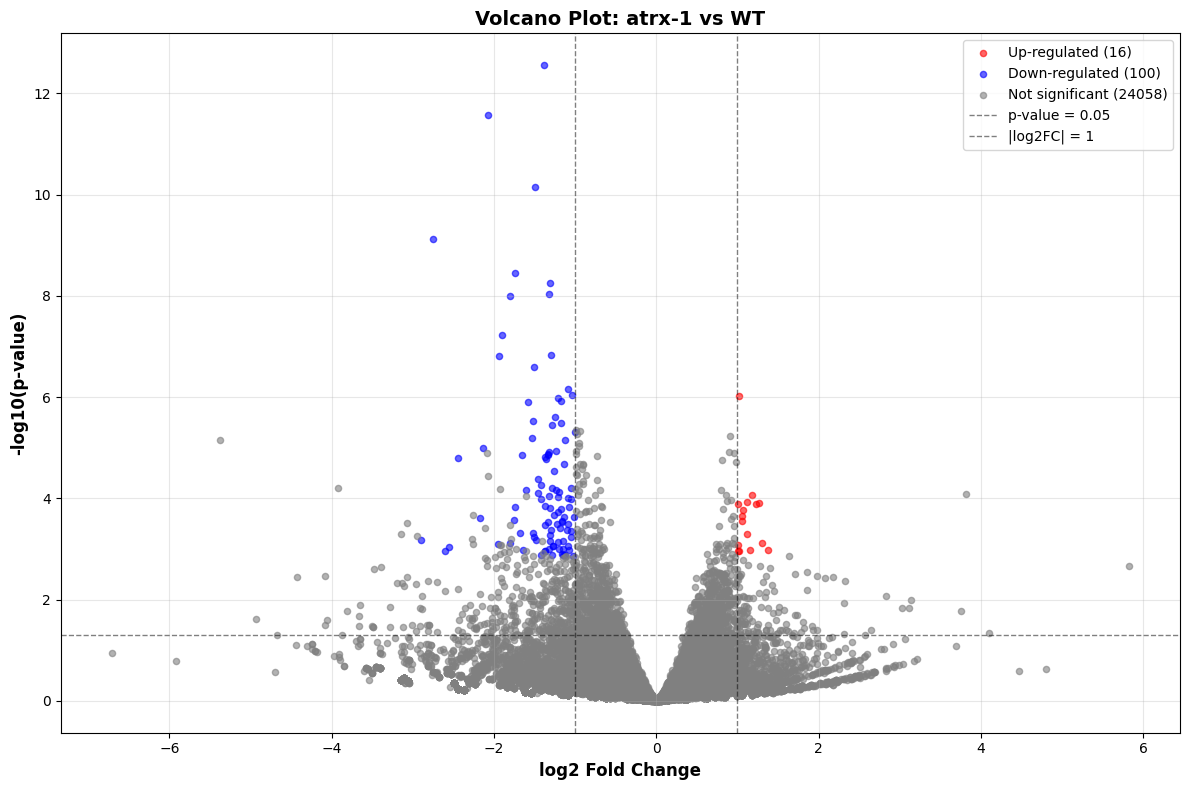

In [17]:
# Volcano plot 그리기
plt.figure(figsize=(12, 8))

color_map = {
    'Up-regulated': 'red',
    'Down-regulated': 'blue',
    'Not significant': 'gray'
}

for sig_type, color in color_map.items():
    subset = results_plot[results_plot['significance'] == sig_type]
    plt.scatter(
        subset['log2FoldChange'],
        subset['-log10(pvalue)'],
        c=color,
        label=f"{sig_type} ({len(subset)})",
        alpha=0.6,
        s=20
    )

# 기준선 추가
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1, alpha=0.5, label='p-value = 0.05')
plt.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='|log2FC| = 1')

# 그래프 꾸미기
plt.xlabel('log2 Fold Change', fontsize=12, fontweight='bold')
plt.ylabel('-log10(p-value)', fontsize=12, fontweight='bold')
plt.title('Volcano Plot: atrx-1 vs WT', fontsize=14, fontweight='bold')
plt.legend(loc='best', frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 결과 요약

분석 결과를 요약합니다.

In [18]:
print("="*60)
print("PyDESeq2 Differential Expression 분석 결과 요약")
print("="*60)
print(f"\n총 분석된 유전자 수: {len(results)}")
print(f"유의한 유전자 수 (padj < 0.05, |log2FC| > 1): {len(sig_genes)}")
print(f"  - Up-regulated: {len(sig_genes[sig_genes['log2FoldChange'] > 1])}")
print(f"  - Down-regulated: {len(sig_genes[sig_genes['log2FoldChange'] < -1])}")
print("\n분석 완료!")

PyDESeq2 Differential Expression 분석 결과 요약

총 분석된 유전자 수: 38618
유의한 유전자 수 (padj < 0.05, |log2FC| > 1): 116
  - Up-regulated: 16
  - Down-regulated: 100

분석 완료!
